In [6]:
%matplotlib inline
## Load per-quadrant tfmodisco patterns + finemo hits + TOMTOM annotations,
## per cell type. Quadrants are (cossim z-scored, lfc) on the full 56k library.
import os, sys, json, h5py, numpy as np, pandas as pd, matplotlib.pyplot as plt

REPO = '/grid/koo/home/pmantill/projects/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra'
sys.path.insert(0, os.path.join(REPO, 'eigen-interactions'))
from eigen_steering import EigenMap

CT    = {'K562': 'K562_twostep_v6_do075', 'HepG2': 'HepG2_twostep_v6_do03'}
CTS   = ['HepG2', 'K562']
QUADS = [1, 2, 3, 4]

MODISCO_DIR = os.path.join(REPO, 'genomic_targets/data/modisco')
QUAD_H5  = lambda ct, q: os.path.join(MODISCO_DIR, f'{ct}_quad_q{q}_enh230_default.h5')
TOMTOM_J = lambda ct, q: os.path.join(MODISCO_DIR, f'tomtom_jaspar2026_{ct}_quad_q{q}_enh230_default.json')
HITS_TSV = lambda ct, q: os.path.join(REPO, 'genomic_targets/data/motif', ct, f'quad_q{q}', 'hits.tsv')

df = pd.read_csv(os.path.join(REPO, 'data', 'joint_library_combined.csv'))
df = df.dropna(subset=['sequence'] + [f'{c}_log2FC' for c in CT]).reset_index(drop=True)

em = EigenMap(model_names=CT, device='cpu')
em.load_from_dataframe(df, seq_col='sequence')

raw = np.load(os.path.join(REPO, 'genomic_targets/data/deeplift_attributions.npz'))
df_full = pd.read_csv(os.path.join(REPO, 'data', 'joint_library_combined.csv'))
seq_valid = df_full['sequence'].notna(); n_full = seq_valid.sum()
keep = df_full.loc[seq_valid, ['sequence'] + [f'{c}_log2FC' for c in CT]].notna().all(axis=1).values
del df_full

ohe = em.X.numpy()
for c in CT:
    hyp = raw[f'attr_{c}'][:n_full][keep]
    em.attr_hyp[c]   = hyp
    em.attr[c]       = hyp * ohe
    em.importance[c] = em.attr[c].sum(axis=1)

cossim = em.cosine_similarity(mode='importance', zscore=True)
lfc    = df['HepG2_log2FC'].values - df['K562_log2FC'].values
fin    = np.isfinite(cossim) & np.isfinite(lfc)
n      = len(df)

quad_indices = {
    1: np.where(fin & (cossim >= 0) & (lfc >= 0))[0],
    2: np.where(fin & (cossim >= 0) & (lfc <  0))[0],
    3: np.where(fin & (cossim <  0) & (lfc <  0))[0],
    4: np.where(fin & (cossim <  0) & (lfc >= 0))[0],
}
quad_of = np.zeros(n, dtype=int)
for q in QUADS: quad_of[quad_indices[q]] = q
quad_n = {q: len(quad_indices[q]) for q in QUADS}

tomtom = {(ct, q): (json.load(open(TOMTOM_J(ct, q))) if os.path.exists(TOMTOM_J(ct, q)) else {})
          for ct in CTS for q in QUADS}

rows = []
for ct in CTS:
    for q in QUADS:
        h5 = QUAD_H5(ct, q)
        if not os.path.exists(h5): continue
        with h5py.File(h5) as f:
            for grp, sign in (('pos_patterns', 'pos'), ('neg_patterns', 'neg')):
                if grp not in f: continue
                for pat in f[grp]:
                    key = f'{grp}.{pat}'
                    rows.append({'ct': ct, 'q': q, 'sign': sign,
                                 'pattern': key, 'tf': tomtom[(ct, q)].get(key, '')})
patterns = pd.DataFrame(rows)

hits = {}
for ct in CTS:
    for q in QUADS:
        f = HITS_TSV(ct, q)
        if not os.path.exists(f): continue
        h = pd.read_csv(f, sep='\t', usecols=['peak_id', 'motif_name', 'hit_importance'])
        h['peak_id'] = h['peak_id'].astype(int)
        h = h[h['peak_id'] < n].copy()
        h['q_dest'] = quad_of[h['peak_id'].values]
        hits[(ct, q)] = h

print(f'n={n}   patterns={len(patterns)}   total hits={sum(len(v) for v in hits.values())}')
print('quad sizes:', quad_n)

EigenMap: ['K562', 'HepG2'], models={'K562': 'K562_twostep_v6_do075', 'HepG2': 'HepG2_twostep_v6_do03'}
Loaded 56975 sequences, X shape: torch.Size([56975, 4, 281])
n=56975   patterns=149   total hits=651671
quad sizes: {1: 23337, 2: 30663, 3: 492, 4: 2483}


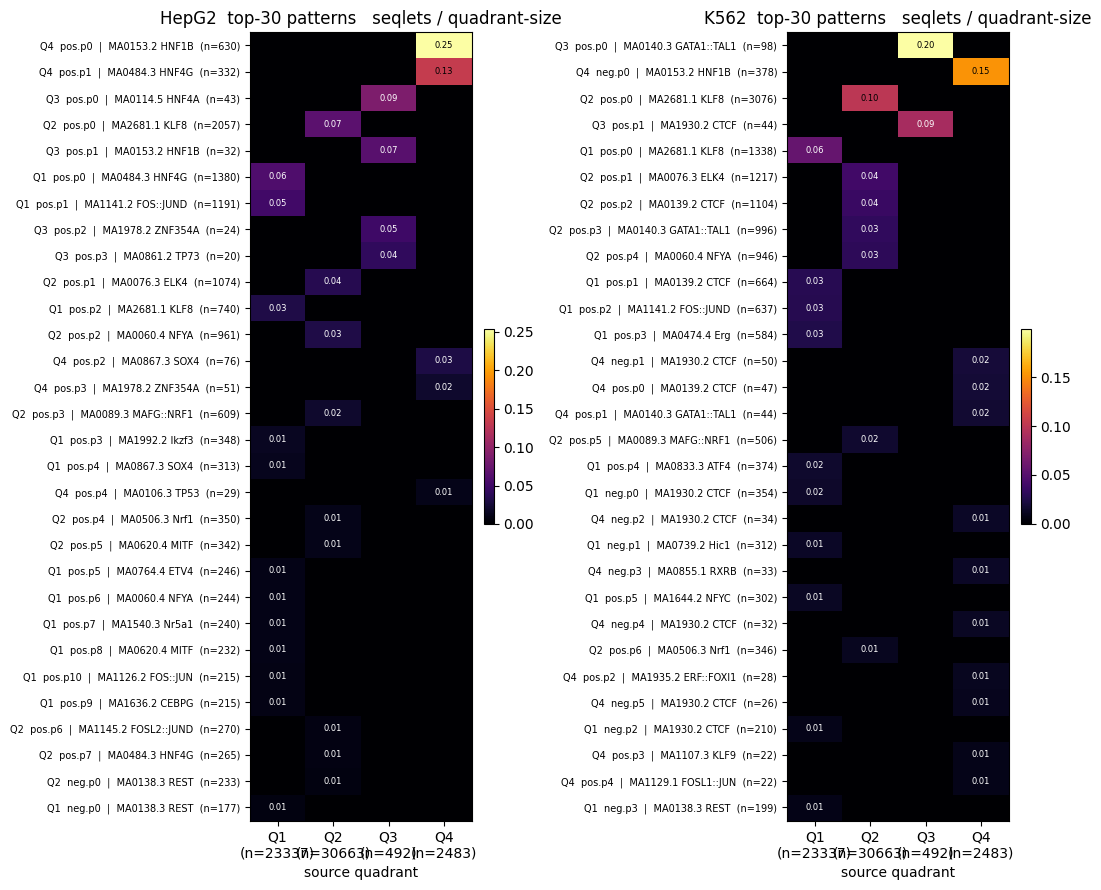

In [7]:
## Pattern enrichment. One row per modisco pattern (no TF aggregation —
## each pattern is already its own clustered unit). Cell = # seqlets / # seqs
## in source quadrant; comparable across quadrants of very different sizes.
TOP_PATS = 30

seqlet_rows = []
for ct in CTS:
    for q in QUADS:
        h5 = QUAD_H5(ct, q)
        if not os.path.exists(h5): continue
        with h5py.File(h5) as f:
            for grp in ('pos_patterns', 'neg_patterns'):
                if grp not in f: continue
                for pat in f[grp]:
                    key = f'{grp}.{pat}'
                    n_seq = len(f[grp][pat]['seqlets']['example_idx'])
                    seqlet_rows.append({'ct': ct, 'q': q, 'pattern': key,
                                        'tf': tomtom[(ct, q)].get(key, ''),
                                        'n_seqlets': n_seq,
                                        'rate': n_seq / max(quad_n[q], 1)})
seqlets_df = pd.DataFrame(seqlet_rows)

fig, axes = plt.subplots(1, 2, figsize=(11, 9))
for ax, ct in zip(axes, CTS):
    sub = (seqlets_df[seqlets_df['ct'] == ct]
           .sort_values('rate', ascending=False).head(TOP_PATS))
    mat = np.zeros((len(sub), len(QUADS)))
    for i, (_, r) in enumerate(sub.iterrows()):
        mat[i, QUADS.index(r['q'])] = r['rate']
    ylabels = [f'Q{r["q"]}  {r["pattern"].replace("_patterns.pattern_", ".p")}  '
               f'|  {r["tf"]}  (n={r["n_seqlets"]})'
               for _, r in sub.iterrows()]

    im = ax.imshow(mat, aspect='auto', cmap='inferno')
    ax.set_xticks(range(len(QUADS)))
    ax.set_xticklabels([f'Q{q}\n(n={quad_n[q]})' for q in QUADS])
    ax.set_yticks(range(len(ylabels))); ax.set_yticklabels(ylabels, fontsize=7)
    ax.set_xlabel('source quadrant')
    ax.set_title(f'{ct}  top-{TOP_PATS} patterns   seqlets / quadrant-size')
    vmax = mat.max() if mat.size else 1
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            v = mat[i, j]
            if v > 0:
                ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=6,
                        color='white' if v < vmax * 0.5 else 'black')
    plt.colorbar(im, ax=ax, fraction=0.04)
plt.tight_layout(); plt.show()

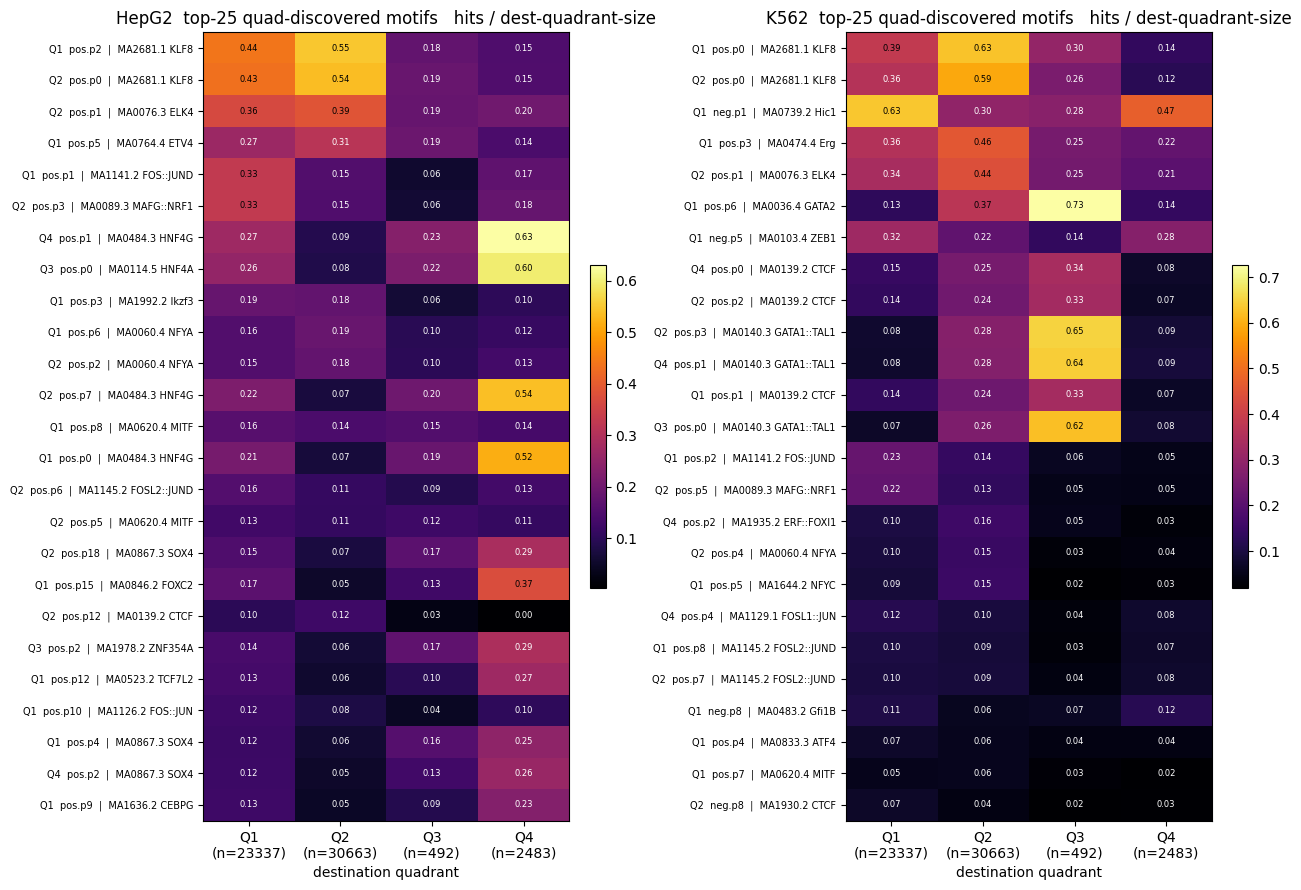

In [8]:
## Hits enrichment. Rows = top quadrant-discovered motifs (q_src, motif),
## cols = destination quadrant on full library, cells = # finemo hits / # seqs
## in destination quadrant; comparable across quadrants of very different sizes.
TOP_PATS = 25

fig, axes = plt.subplots(1, 2, figsize=(13, 9))
for ax, ct in zip(axes, CTS):
    parts = []
    for q in QUADS:
        if (ct, q) not in hits: continue
        m = (hits[(ct, q)].groupby(['motif_name', 'q_dest']).size()
                          .unstack('q_dest', fill_value=0)
                          .reindex(columns=QUADS, fill_value=0))
        m.index = pd.MultiIndex.from_product([[q], m.index], names=['q_src', 'motif'])
        parts.append(m)
    mat_count = pd.concat(parts) if parts else pd.DataFrame()
    mat_count = mat_count.loc[mat_count.sum(axis=1).sort_values(ascending=False).head(TOP_PATS).index]
    norm = np.array([max(quad_n[q], 1) for q in QUADS], dtype=float)
    mat = mat_count.values / norm[None, :]

    ylabels = [f'Q{qs}  {motif.replace("_patterns.pattern_", ".p")}  |  {tomtom[(ct, qs)].get(motif, "")}'
               for (qs, motif) in mat_count.index]
    im = ax.imshow(mat, aspect='auto', cmap='inferno')
    ax.set_xticks(range(len(QUADS)))
    ax.set_xticklabels([f'Q{q}\n(n={quad_n[q]})' for q in QUADS])
    ax.set_yticks(range(len(ylabels))); ax.set_yticklabels(ylabels, fontsize=7)
    ax.set_xlabel('destination quadrant')
    ax.set_title(f'{ct}  top-{TOP_PATS} quad-discovered motifs   hits / dest-quadrant-size')
    vmax = mat.max() if mat.size else 1
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            v = mat[i, j]
            if v > 0:
                ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=6,
                        color='white' if v < vmax * 0.5 else 'black')
    plt.colorbar(im, ax=ax, fraction=0.04)
plt.tight_layout(); plt.show()

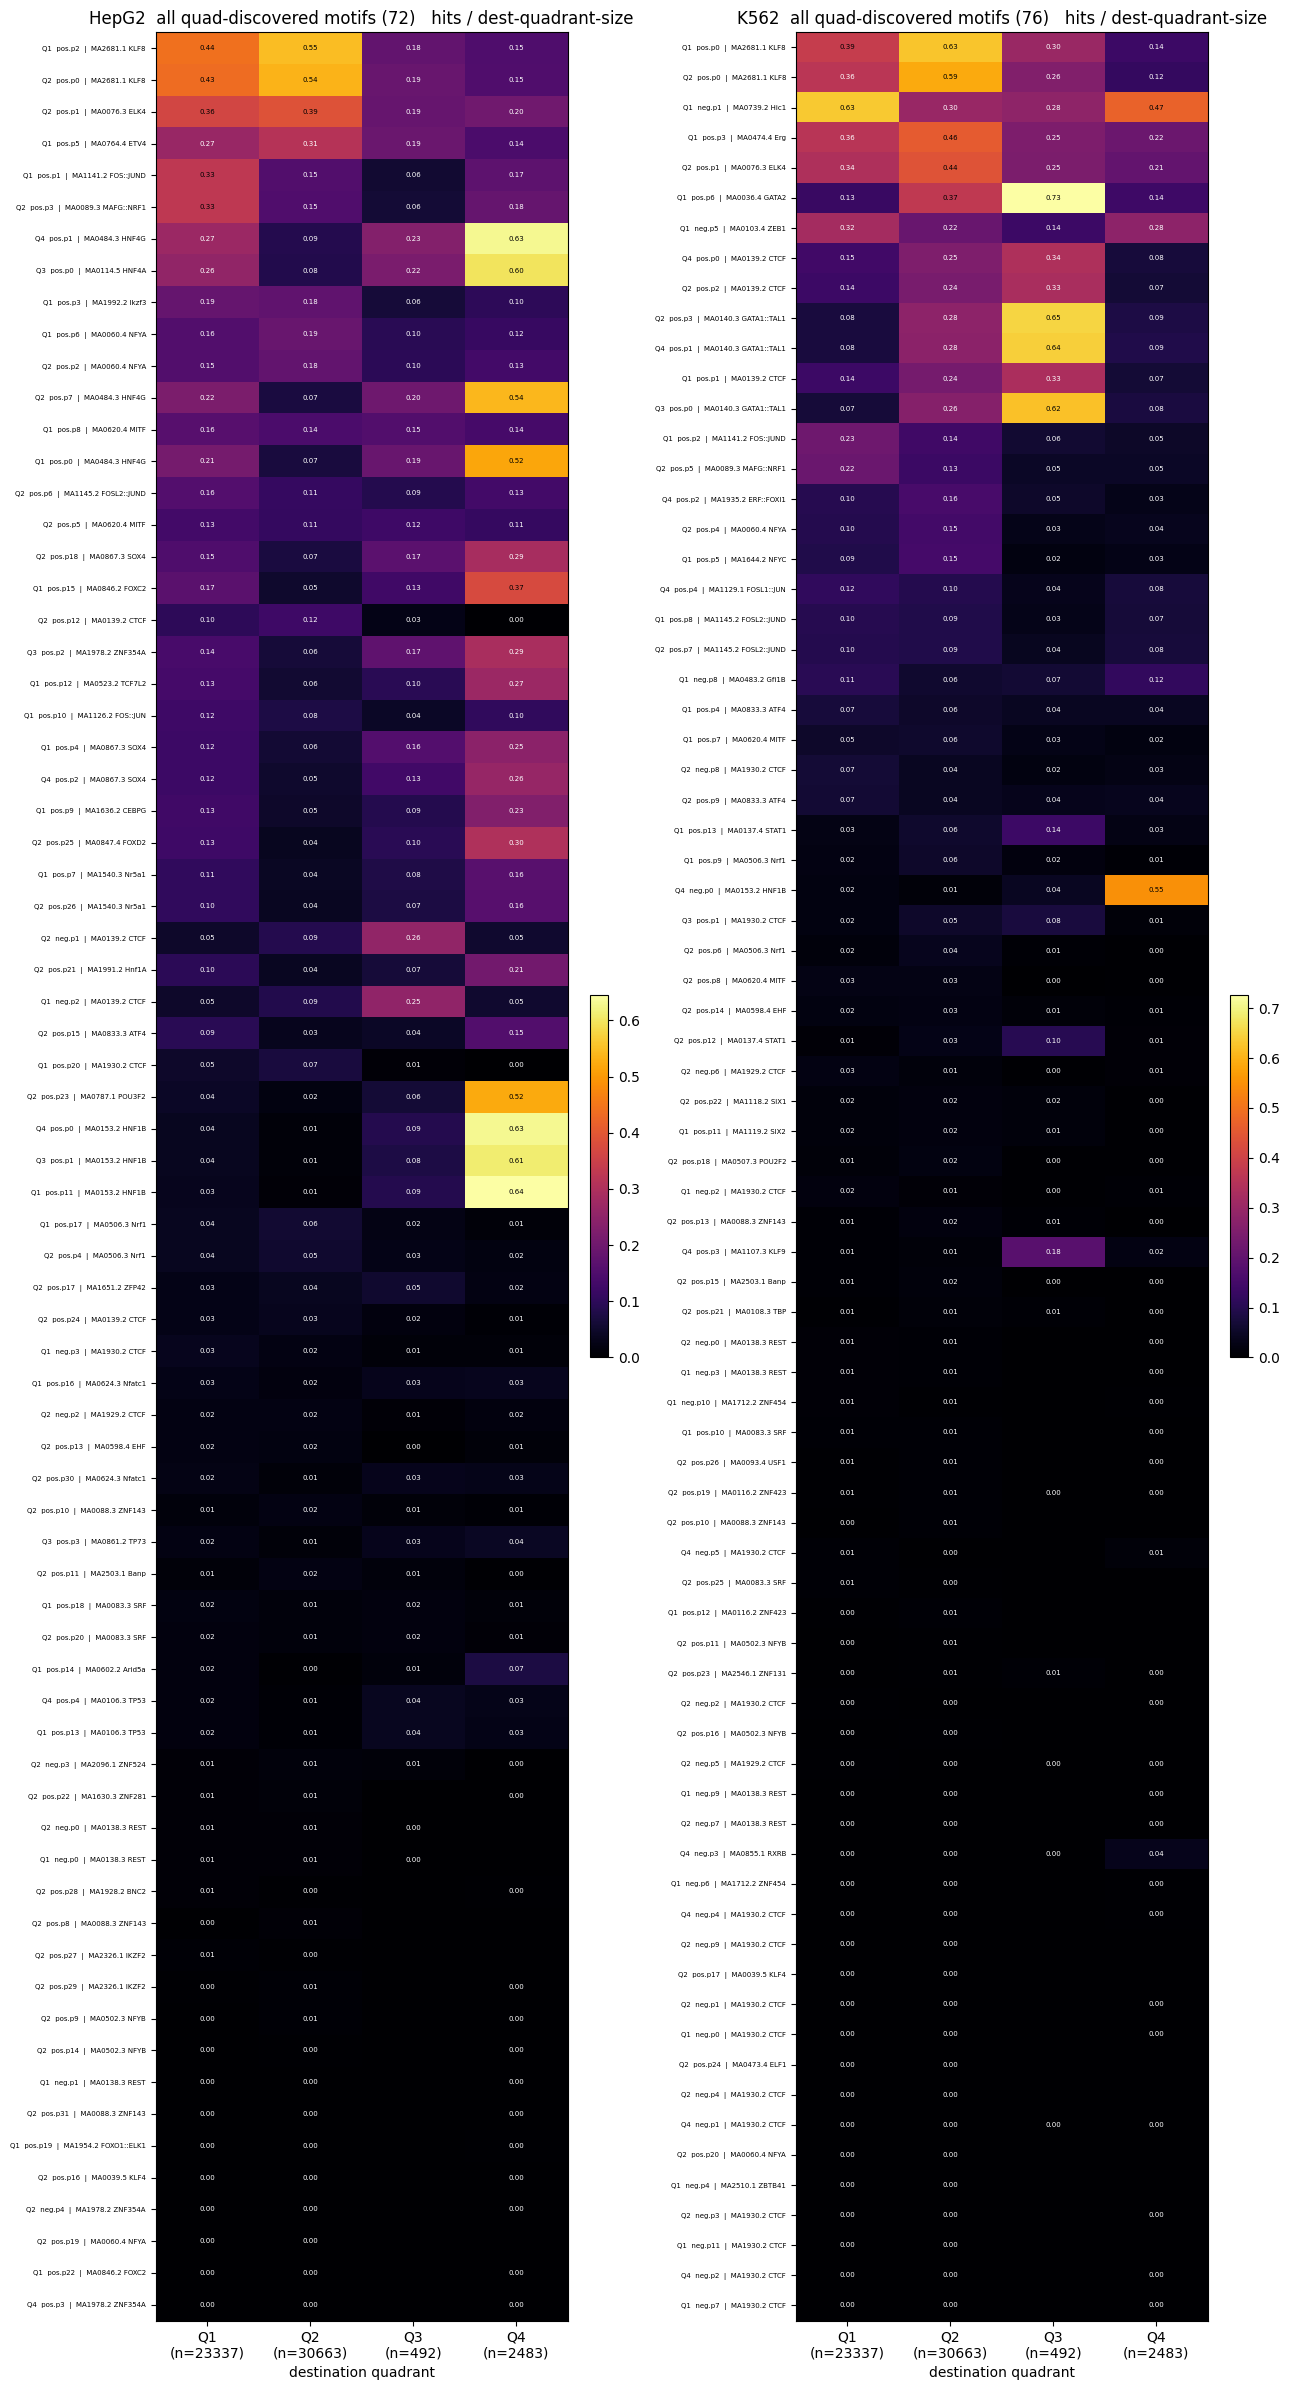

In [9]:
## Same as above but no TOP_PATS filter — every quad-discovered motif shown,
## sorted by total hits across destination quadrants.
fig, axes = plt.subplots(1, 2, figsize=(13, 24))
for ax, ct in zip(axes, CTS):
    parts = []
    for q in QUADS:
        if (ct, q) not in hits: continue
        m = (hits[(ct, q)].groupby(['motif_name', 'q_dest']).size()
                          .unstack('q_dest', fill_value=0)
                          .reindex(columns=QUADS, fill_value=0))
        m.index = pd.MultiIndex.from_product([[q], m.index], names=['q_src', 'motif'])
        parts.append(m)
    mat_count = pd.concat(parts) if parts else pd.DataFrame()
    mat_count = mat_count.loc[mat_count.sum(axis=1).sort_values(ascending=False).index]
    norm = np.array([max(quad_n[q], 1) for q in QUADS], dtype=float)
    mat = mat_count.values / norm[None, :]

    ylabels = [f'Q{qs}  {motif.replace("_patterns.pattern_", ".p")}  |  {tomtom[(ct, qs)].get(motif, "")}'
               for (qs, motif) in mat_count.index]
    im = ax.imshow(mat, aspect='auto', cmap='inferno')
    ax.set_xticks(range(len(QUADS)))
    ax.set_xticklabels([f'Q{q}\n(n={quad_n[q]})' for q in QUADS])
    ax.set_yticks(range(len(ylabels))); ax.set_yticklabels(ylabels, fontsize=5)
    ax.set_xlabel('destination quadrant')
    ax.set_title(f'{ct}  all quad-discovered motifs ({len(ylabels)})   hits / dest-quadrant-size')
    vmax = mat.max() if mat.size else 1
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            v = mat[i, j]
            if v > 0:
                ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=5,
                        color='white' if v < vmax * 0.5 else 'black')
    plt.colorbar(im, ax=ax, fraction=0.04)
plt.tight_layout(); plt.show()

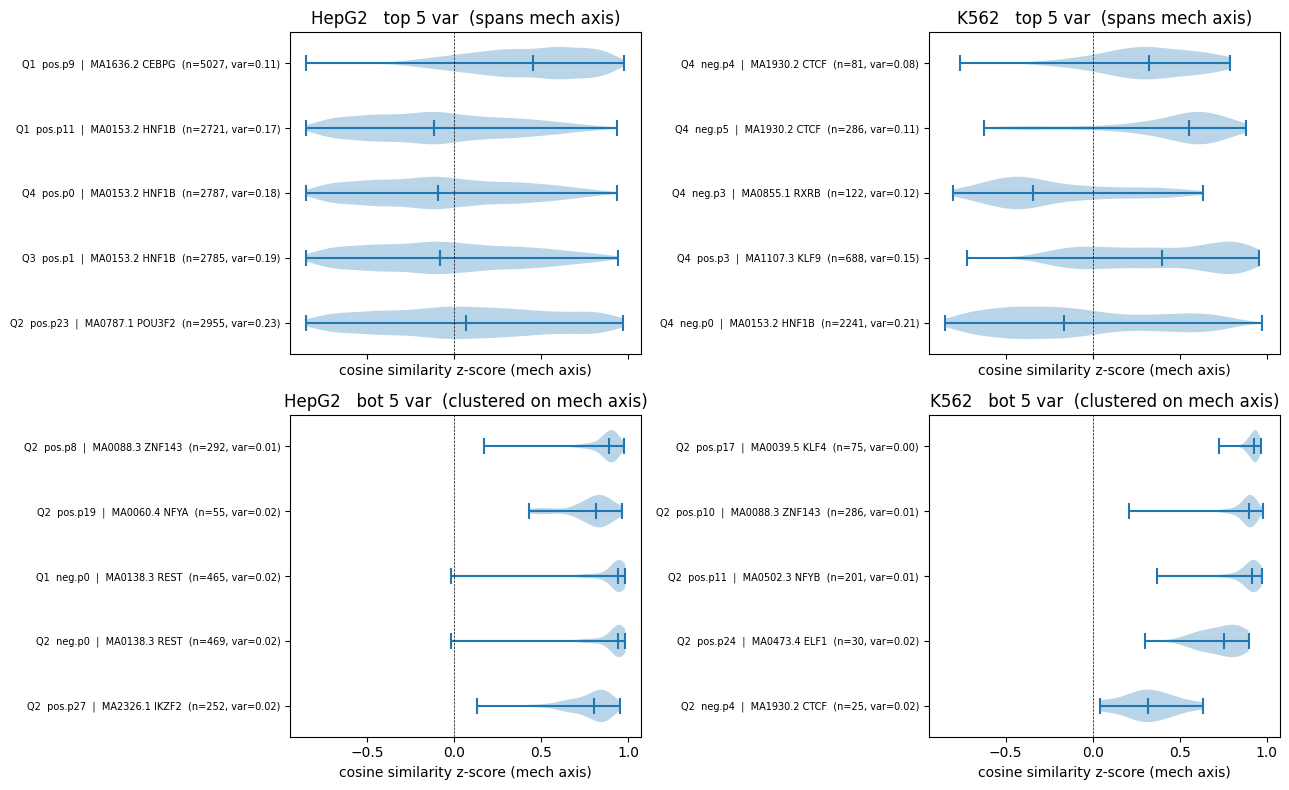

In [10]:
## Variance of mech axis (cossim z-score) across each pattern's hit-bearing seqs.
## Top 5  = patterns whose hits span the mech axis (cell-type-shared use).
## Bot 5  = patterns whose hits cluster on the mech axis (cell-type-specific use).
MIN_HITS = 20

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
for col, ct in enumerate(CTS):
    pat_cs = {}
    for q in QUADS:
        if (ct, q) not in hits: continue
        for motif, sub in hits[(ct, q)].groupby('motif_name'):
            cs = cossim[sub['peak_id'].values]
            cs = cs[np.isfinite(cs)]
            if len(cs) >= MIN_HITS:
                pat_cs[(q, motif)] = cs
    if not pat_cs: continue
    var_s = pd.Series({k: v.var() for k, v in pat_cs.items()}).sort_values(ascending=False)

    for row, (title, sel) in enumerate([('top 5 var  (spans mech axis)',  var_s.head(5)),
                                         ('bot 5 var  (clustered on mech axis)', var_s.tail(5))]):
        ax = axes[row, col]
        data   = [pat_cs[k] for k in sel.index]
        labels = [f'Q{qs}  {motif.replace("_patterns.pattern_", ".p")}  |  '
                  f'{tomtom[(ct, qs)].get(motif, "")}  '
                  f'(n={len(pat_cs[(qs, motif)])}, var={var_s[(qs, motif)]:.2f})'
                  for (qs, motif) in sel.index]
        ax.violinplot(data, positions=range(len(data)), showmedians=True, vert=False)
        ax.set_yticks(range(len(data))); ax.set_yticklabels(labels, fontsize=7)
        ax.axvline(0, color='k', lw=0.5, ls='--')
        ax.set_xlabel('cosine similarity z-score (mech axis)')
        ax.set_title(f'{ct}   {title}')
plt.tight_layout(); plt.show()

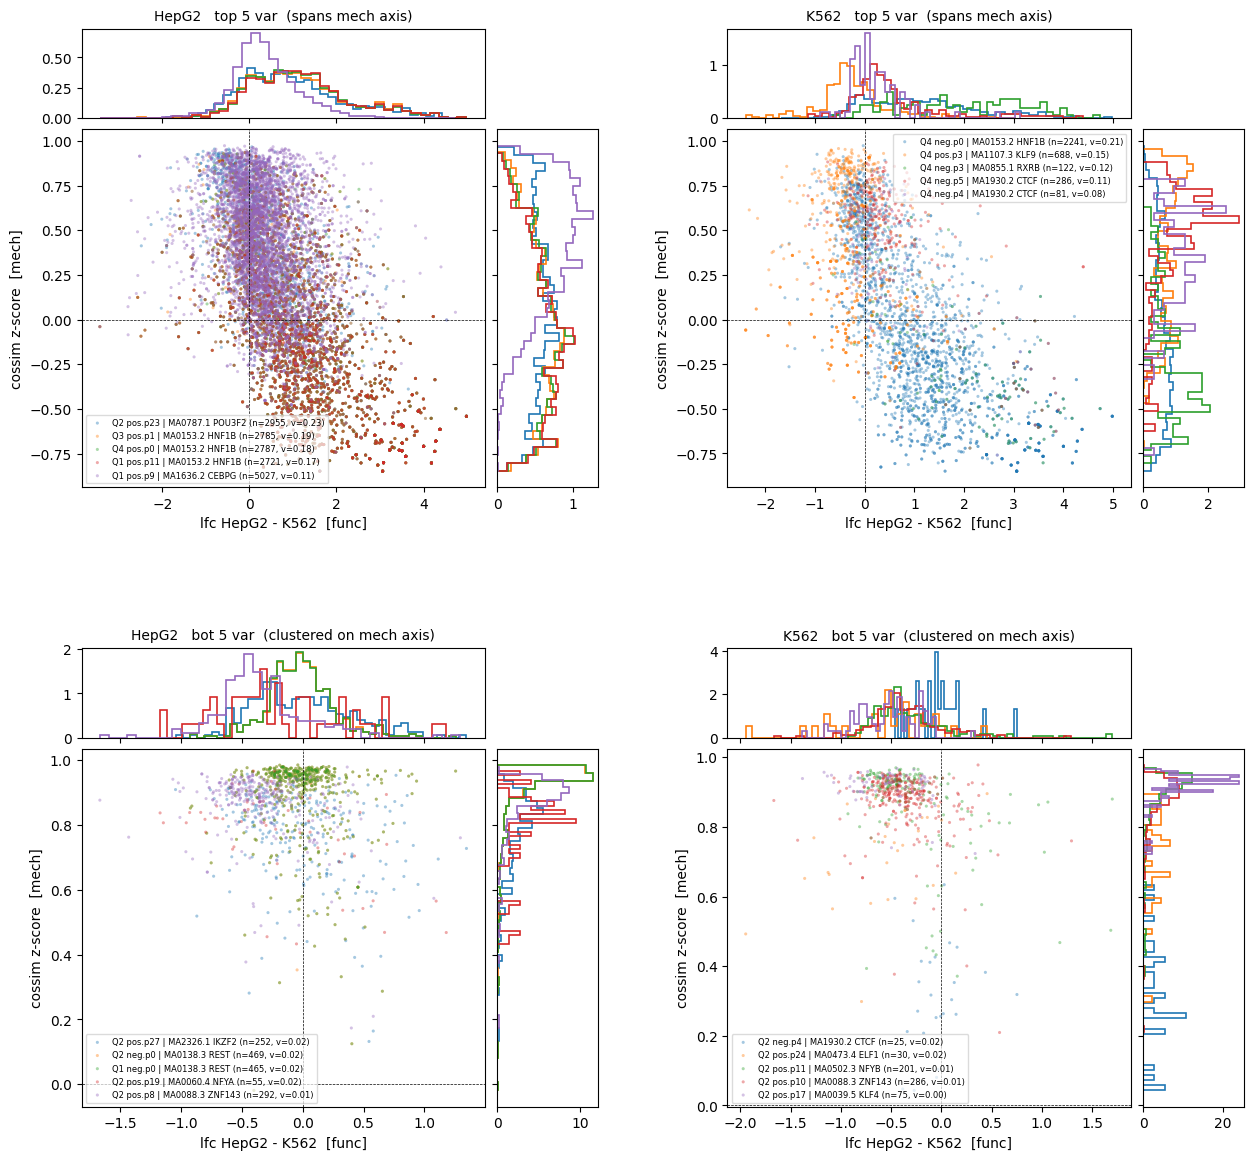

In [11]:
## Same top-5 / bot-5 variance patterns, on mech (y) x func (x) space.
## Joint scatter + marginal distributions per pattern.
MIN_HITS = 20
COLORS = plt.cm.tab10(np.linspace(0, 1, 10))

fig = plt.figure(figsize=(15, 14))
outer = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.25)

for col, ct in enumerate(CTS):
    pat = {}
    for q in QUADS:
        if (ct, q) not in hits: continue
        for motif, sub in hits[(ct, q)].groupby('motif_name'):
            pids = sub['peak_id'].values
            cs = cossim[pids]; lf = lfc[pids]
            mask = np.isfinite(cs) & np.isfinite(lf)
            if mask.sum() >= MIN_HITS:
                pat[(q, motif)] = (lf[mask], cs[mask])
    if not pat: continue
    var_s = pd.Series({k: v[1].var() for k, v in pat.items()}).sort_values(ascending=False)

    for row, (title, sel) in enumerate([('top 5 var  (spans mech axis)', var_s.head(5)),
                                         ('bot 5 var  (clustered on mech axis)', var_s.tail(5))]):
        inner = outer[row, col].subgridspec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4],
                                            hspace=0.05, wspace=0.05)
        ax_m = fig.add_subplot(inner[1, 0])
        ax_t = fig.add_subplot(inner[0, 0], sharex=ax_m)
        ax_r = fig.add_subplot(inner[1, 1], sharey=ax_m)
        ax_t.tick_params(labelbottom=False); ax_r.tick_params(labelleft=False)

        for i, (qs, motif) in enumerate(sel.index):
            lf, cs = pat[(qs, motif)]
            c = COLORS[i % 10]
            label = (f'Q{qs} {motif.replace("_patterns.pattern_", ".p")} | '
                     f'{tomtom[(ct, qs)].get(motif, "")} (n={len(lf)}, v={var_s[(qs, motif)]:.2f})')
            ax_m.scatter(lf, cs, s=5, alpha=0.4, color=c, label=label, edgecolor='none')
            ax_t.hist(lf, bins=40, histtype='step', density=True, color=c, lw=1.2)
            ax_r.hist(cs, bins=40, histtype='step', density=True, color=c, lw=1.2,
                      orientation='horizontal')
        ax_m.axhline(0, color='k', lw=0.5, ls='--'); ax_m.axvline(0, color='k', lw=0.5, ls='--')
        ax_m.set_xlabel('lfc HepG2 - K562  [func]')
        ax_m.set_ylabel('cossim z-score  [mech]')
        ax_m.legend(fontsize=6, loc='best', framealpha=0.7)
        ax_t.set_title(f'{ct}   {title}', fontsize=10)
plt.show()